In [3]:
import os

import cv2
import geopandas as gpd
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch

from IPython.display import Image
from osgeo import gdal
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds, transform as window_transform
from shapely.geometry import Point

device = 'mps'

In [37]:
def get_bbox_bounds(point_gdf, side_length):
    """
    Given a GeoDataFrame with a single point geometry, return (xmin, xmax, ymin, ymax)
    for a square bounding box of given side_length centered at the point.
    """
    half_size = side_length / 2
    x = point_gdf.geometry.iloc[0].x
    y = point_gdf.geometry.iloc[0].y
    xmin = x - half_size
    xmax = x + half_size
    ymin = y - half_size
    ymax = y + half_size
    return xmin, ymin, xmax, ymax

def load_chips(
    point_gdf,
    unregistered_path,
    registered_path,
    side_length
) -> tuple:
    """
    Read matching window chips from an unregistered and a registered raster,
    storing pixel arrays, profiles, and windows for GCP generation.

    Args:
        point_gdf (GeoDataFrame): single-point geometry in the SRC of unregistered image.
        unregistered_path (str): path/URL to the poorly-referenced raster.
        registered_path (str): path/URL to the well-referenced raster.
        side_length (float): length of the square side (in CRS units) around the point.

    Returns:
        tuple: (un_chip, reg_chip), each a Chip(array, profile, window).
    """
    # Determine bounding box around the point
    bbox = get_bbox_bounds(point_gdf, side_length)

    # Unregistered chip
    with rasterio.open(unregistered_path) as un_ds:
        un_window = from_bounds(*bbox, un_ds.transform)
        un_array = un_ds.read(window=un_window)
        un_profile = un_ds.profile
        un_crs = un_ds.crs

    un_chip = dict(array=un_array, profile=un_profile, window=un_window)

    # Registered chip: warp to unregistered CRS
    with rasterio.open(registered_path) as reg_ds:
        with WarpedVRT(
            reg_ds,
            crs=un_crs,
            resampling=Resampling.bilinear
        ) as vrt:
            reg_window = from_bounds(*bbox, vrt.transform)
            reg_array = vrt.read(window=reg_window)
            reg_profile = vrt.profile

    reg_chip = dict(array=reg_array, profile=reg_profile, window=reg_window)

    return un_chip, reg_chip

def rasterio_to_torch_tensor(numpy_array: np.ndarray, bands: int = [0, 1, 2]) -> torch.Tensor:
    """
    Converts a rasterio NumPy array from rasterio window output (C X H x W)
    to a PyTorch tensor of shape (1, C, H, W).

    Args:
        numpy_array: Input NumPy array with shape (C, H, W).

    Returns:
        PyTorch tensor with shape (1, C, H, W).
    """
    # Add batch dimension: (C, H, W) -> (1, C, H, W)
    tensor = torch.from_numpy(numpy_array[bands]).unsqueeze(0)

    return tensor

def get_loftr_matches(img1, img2, device: str = 'cpu'):
    """
    Finds keypoint matches between two images using LoFTR, and plots the grayscale images.

    Args:
        img1_np: NumPy array of the first image (C, H, W).
        img2_np: NumPy array of the second image (C, H, W).

    Returns:
        A tuple containing:
            - mkpts0 (np.ndarray): Matched keypoints in image 0 (N, 2).
            - mkpts1 (np.ndarray): Matched keypoints in image 1 (N, 2).
            - inliers (np.ndarray): Boolean array indicating inlier matches (N,).
    """

    # 1) load & cast to float, normalize to [0,1]
    img1_tensor = rasterio_to_torch_tensor(img1).float().div(255.0).to(device)
    img2_tensor = rasterio_to_torch_tensor(img2).float().div(255.0).to(device)

    # Convert to grayscale for LoFTR
    img1_gray = K.color.rgb_to_grayscale(img1_tensor)
    img2_gray = K.color.rgb_to_grayscale(img2_tensor)
    
    # LoFTR matching
    matcher = KF.LoFTR(pretrained='outdoor').to(device)

    input_dict = {
        "image0": img1_gray,  # LoFTR works on grayscale images
        "image1": img2_gray,
    }

    with torch.inference_mode():
        correspondences = matcher(input_dict)

    mkpts0 = correspondences["keypoints0"].cpu().numpy()
    mkpts1 = correspondences["keypoints1"].cpu().numpy()

    # OpenCV's findFundamentalMat expects N, 1, 2 or N, 2 shape for points
    # LoFTR outputs N, 2, so it's compatible
    if mkpts0.shape[0] >= 7 and mkpts1.shape[0] >= 7: # findFundamentalMat requires at least 7 points
        Fm, inliers_cv = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
        inliers = inliers_cv.ravel() > 0
    else:
        # Not enough points to compute F, consider all as tentative or handle as needed
        print(f"Warning: Not enough keypoints to compute Fundamental Matrix (found {mkpts0.shape[0]}). Returning all as tentative.")
        inliers = np.zeros(mkpts0.shape[0], dtype=bool) # Or np.ones if you want to consider all as inliers


    return mkpts0, mkpts1, inliers

def generate_gcps(un_chip: dict,
                  reg_chip: dict,
                  device: str = 'cpu') -> list:
    """
    Generate GDAL GCPs from inlier LoFTR matches between a poorly-referenced chip
    (un_chip) and a well-referenced chip (reg_chip).

    Only matches marked True in the inliers mask get turned into GCPs.

    Args:
        un_chip: dict with keys 'array', 'profile', 'window'
        reg_chip: same for the registered chip
        device: torch device for LoFTR matching

    Returns:
        List of osgeo.gdal.GCP objects with pixel/line in the full unregistered image
        and X/Y from the registered image. Returns an empty list if no reliable matches.
    """
    # 1) get all matches + boolean mask
    mkpts_reg, mkpts_un, inliers = get_loftr_matches(
        reg_chip['array'],
        un_chip['array'],
        device
    )
    mkpts_reg = np.asarray(mkpts_reg)
    mkpts_un  = np.asarray(mkpts_un)
    inliers   = np.asarray(inliers)

    # 2) if no matches at all, or no inliers, bail out early
    if mkpts_reg.size == 0 or mkpts_un.size == 0 or not np.any(inliers):
        # Optionally log or warn here
        print("No valid GCPs could be generated (no inliers).")
        return []

    # 3) pick only the inlier points
    reg_pts = mkpts_reg[inliers]
    un_pts  = mkpts_un[inliers]

    # 4) prepare transforms & offsets
    tf_reg     = window_transform(reg_chip['window'], reg_chip['profile']['transform'])
    col_off_un = un_chip['window'].col_off
    row_off_un = un_chip['window'].row_off

    # 5) build GCP list
    gcps: list = []
    for (cx, ry), (ux, uy) in zip(reg_pts, un_pts):
        geo_x, geo_y = tf_reg * (float(cx), float(ry))
        pixel = float(ux + col_off_un)
        line  = float(uy + row_off_un)
        gcps.append(gdal.GCP(geo_x, geo_y, 0.0, pixel, line))

    return gcps

def save_chip(chip: dict, out_path: str):
    """
    Save a chip (with array, profile, window) back to a GeoTIFF.

    Args:
        chip: dict with keys
            - 'array'   : C×H×W NumPy array
            - 'profile' : original rasterio profile dict
            - 'window'  : rasterio.windows.Window used to read this chip
        out_path: path to write the GeoTIFF
    """
    # Copy and update the profile to reflect just this window
    profile = chip['profile'].copy()
    # array shape is (C, H, W)
    _, H, W = chip['array'].shape

    # Compute an affine for the window
    new_transform = window_transform(chip['window'], profile['transform'])

    profile.update({
        'height': H,
        'width' : W,
        'transform': new_transform,
        'driver':  'GTiff'
    })

    # Write out
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(chip['array'])
    return out_path
    


In [43]:
unreg_path = '/Users/kdoherty/tidy_drone_survey/data/raster/batch_5_test.tif'
reg_path = 'https://storage.googleapis.com/mpg-aerial-survey/surveys/2024_front_country/processing/dronedeploy/front_country_2024.tif'

x_coord = 254636
y_coord = 283226
side_length = 50
epsg_code = 6514

# Create GeoDataFrames for the original point in both CRSs
test_point = gpd.GeoDataFrame({'geometry': [Point(x_coord, y_coord)]}, crs=f"EPSG:{epsg_code}")

In [44]:
un_chip, reg_chip = load_chips(test_point, unreg_path, reg_path, side_length)
gcps = generate_gcps(un_chip, reg_chip, device='mps')
#unregistered_chip_path = save_chip(un_chip, "/Users/kdoherty/tidy_drone_survey/data/raster/un_chip.tif")

In [45]:

out_vrt    = '/Users/kdoherty/tidy_drone_survey/data/raster/test_corrected.vrt'
out_tif    = '/Users/kdoherty/tidy_drone_survey/data/raster/test_corrected.tif'

# 1) Build the CLI-style "-gcp" args for gdal_translate
translate_opts = ["-of", "VRT"]
for g in gcps:
    translate_opts += [
        "-gcp",
        str(g.GCPPixel), str(g.GCPLine),
        str(g.GCPX),     str(g.GCPY),
    ]

# 2) Create a VRT with your GCPs embedded
#    (this is exactly what `gdal_translate -of VRT -gcp ...` does)
vrt_ds = gdal.Translate(
    out_vrt,
    unreg_path,
    options=translate_opts
)
vrt_ds = None  # flush & close

# 3) Now warp the VRT into a GeoTIFF, fitting a 3rd-order polynomial
un_crs = un_chip['profile']['crs'].to_string()  # e.g. "EPSG:6514"
warp_opts = [
    "-of",    "GTiff",
    "-order", "3",       # polynomialOrder = 3
    "-r",     "cubic",   # resampling
    "-t_srs", un_crs,   # target CRS
]

# 4) Apply the warp
out_ds = gdal.Warp(
    out_tif,
    out_vrt,
    options=warp_opts
)
out_ds = None  # flush & close

863 863
Registration successful. ms_img_registered is ready.
GIF saved to extras/rgb_ms_side_by_side.gif (rgb side-by-side, ms side-by-side, with white background, white separator, and persistent black titles)


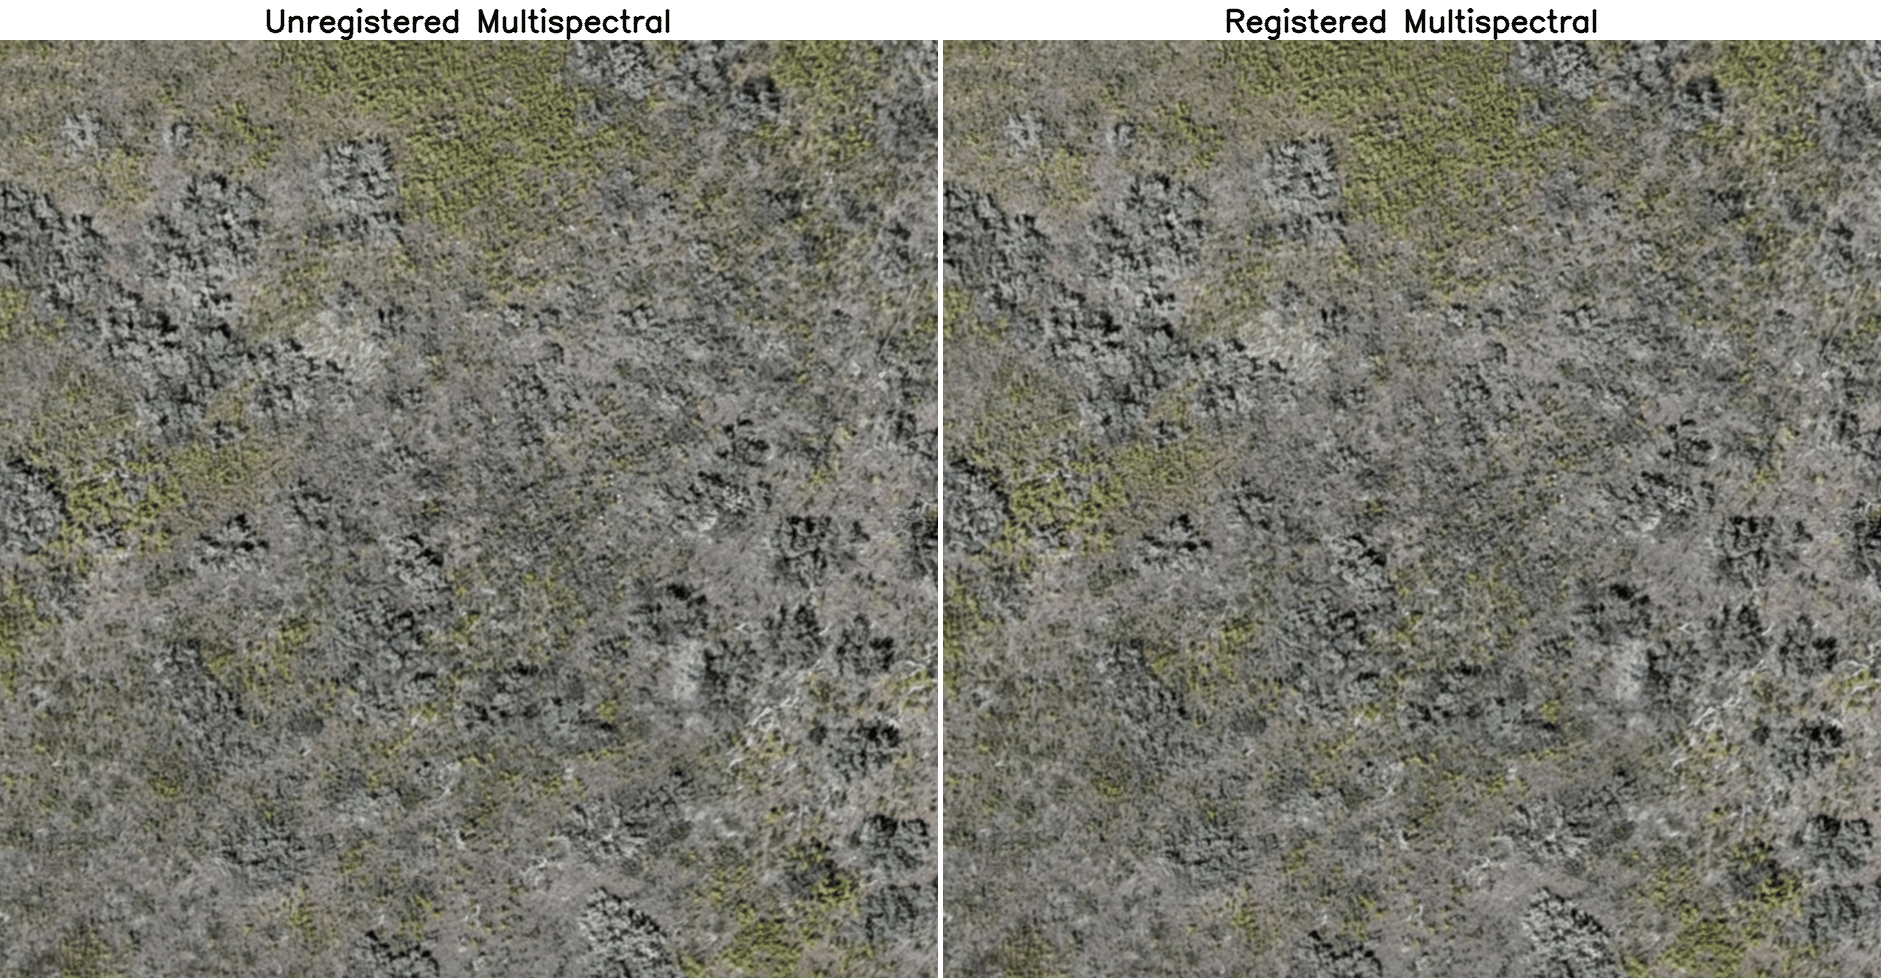

In [9]:
# import cv2
# import numpy as np
# import imageio
# import os

# # 1. Filter keypoints using the inliers_mask
# pts_rgb = keypts_1[inliers].reshape(-1, 1, 2).astype(np.float32)
# pts_ms = keypts_2[inliers].reshape(-1, 1, 2).astype(np.float32)
# print(len(pts_rgb), len(pts_ms))
# # Ensure you have enough inlier points (at least 4 for homography)
# if pts_rgb.shape[0] >= 4 and pts_ms.shape[0] >= 4:
#     # 2. Estimate Transformation (Homography)
#     H, mask_homography = cv2.findHomography(pts_ms, pts_rgb, cv2.RANSAC, 15.0)

#     if H is not None:
#         # 3. Apply Transformation
#         # Convert rgb_crop and ms_crop (C x H x W) to H x W x C for OpenCV
#         rgb_img = np.transpose(rgb_crop, (1, 2, 0))
#         ms_img = np.transpose(ms_crop[:3], (1, 2, 0))
#         height, width = rgb_img.shape[:2]
#         ms_img_registered = cv2.warpPerspective(ms_img, H, (width, height))

#         print("Registration successful. ms_img_registered is ready.")

#         # Prepare output directory
#         os.makedirs("extras", exist_ok=True)

#         # Ensure both images are 3-channel uint8 for GIFs
#         def to_uint8(img):
#             if img.dtype != np.uint8:
#                 img = np.clip(img, 0, 255)
#                 img = img.astype(np.uint8)
#             if img.ndim == 2:
#                 img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
#             elif img.shape[2] == 1:
#                 img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
#             elif img.shape[2] == 4:
#                 img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
#             return img

#         rgb_img_gif = to_uint8(rgb_img)
#         ms_img_gif = to_uint8(ms_img)
#         ms_img_registered_gif = to_uint8(ms_img_registered)

#         # Resize ms_img and ms_img_registered to match rgb_img if needed
#         if ms_img_gif.shape[:2] != rgb_img_gif.shape[:2]:
#             ms_img_gif = cv2.resize(ms_img_gif, (rgb_img_gif.shape[1], rgb_img_gif.shape[0]))
#         if ms_img_registered_gif.shape[:2] != rgb_img_gif.shape[:2]:
#             ms_img_registered_gif = cv2.resize(ms_img_registered_gif, (rgb_img_gif.shape[1], rgb_img_gif.shape[0]))

#         # Parameters for layout
#         line_width = 5
#         title_height = 40
#         font_scale = 1.0
#         thickness = 2
#         font = cv2.FONT_HERSHEY_SIMPLEX

#         # Helper to add a white title bar with black text
#         def add_title_bar(img_left, img_right, title_left, title_right, height=title_height):
#             total_width = img_left.shape[1] + img_right.shape[1] + line_width
#             bar = np.ones((height, total_width, 3), dtype=np.uint8) * 255  # white bar

#             # Left title
#             text_size_left, _ = cv2.getTextSize(title_left, font, font_scale, thickness)
#             x_left = (img_left.shape[1] - text_size_left[0]) // 2
#             y = (height + text_size_left[1]) // 2
#             cv2.putText(bar, title_left, (x_left, y), font, font_scale, (0,0,0), thickness, cv2.LINE_AA)

#             # Right title
#             text_size_right, _ = cv2.getTextSize(title_right, font, font_scale, thickness)
#             x_right = img_left.shape[1] + line_width + (img_right.shape[1] - text_size_right[0]) // 2
#             cv2.putText(bar, title_right, (x_right, y), font, font_scale, (0,0,0), thickness, cv2.LINE_AA)

#             return bar

#         # Helper to pad images to the same height
#         def pad_to_height(img, target_height, color=255):
#             if img.shape[0] < target_height:
#                 pad_amt = target_height - img.shape[0]
#                 pad = np.ones((pad_amt, img.shape[1], 3), dtype=np.uint8) * color
#                 return np.vstack([img, pad])
#             elif img.shape[0] > target_height:
#                 return img[:target_height, ...]
#             return img

#         # Make white vertical line
#         def make_white_line(height, width):
#             return np.ones((height, width, 3), dtype=np.uint8) * 255

#         # --- Compose MS side-by-side ---
#         ms_h = max(ms_img_gif.shape[0], ms_img_registered_gif.shape[0])
#         ms_img_gif_padded = pad_to_height(ms_img_gif, ms_h, color=255)
#         ms_img_registered_gif_padded = pad_to_height(ms_img_registered_gif, ms_h, color=255)
#         ms_white_line = make_white_line(ms_h, line_width)
#         ms_side = np.concatenate([ms_img_gif_padded, ms_white_line, ms_img_registered_gif_padded], axis=1)

#         # --- Compose RGB side-by-side (show same image on both sides for visual alignment) ---
#         rgb_h = rgb_img_gif.shape[0]
#         rgb_img_gif_padded = pad_to_height(rgb_img_gif, rgb_h, color=255)
#         rgb_white_line = make_white_line(rgb_h, line_width)
#         rgb_side = np.concatenate([rgb_img_gif_padded, rgb_white_line, rgb_img_gif_padded], axis=1)

#         # --- Add persistent titles ---
#         title_bar = add_title_bar(
#             ms_img_gif_padded, ms_img_registered_gif_padded,
#             "Unregistered Multispectral", "Registered Multispectral"
#         )
#         ms_side_titled = np.vstack([title_bar, ms_side])
#         rgb_side_titled = np.vstack([title_bar, rgb_side])

#         fname = "extras/rgb_ms_side_by_side.gif"

#         # Save a single GIF alternating between rgb side-by-side and ms side-by-side
#         imageio.mimsave(
#             fname,
#             [rgb_side_titled, ms_side_titled],
#             duration=1500,
#             loop=0  # 0 means infinite loop in GIF
#         )

#         print("GIF saved to extras/rgb_ms_side_by_side.gif (rgb side-by-side, ms side-by-side, with white background, white separator, and persistent black titles)")
#     else:
#         print("Homography estimation failed. Not enough consistent inliers after RANSAC.")
# else:
#     print(f"Not enough inlier points to estimate homography. Need at least 4, got {pts_rgb.shape[0]}.")

# Image(fname)
